# 13 — FASE 4: síntesis comparativa de los 12 detectores de régimen

Esta es la **síntesis honesta** del banco de pruebas. No buscamos "el mejor detector": cada
familia gana en un **eje** distinto y la comparación debe ser **justa** (controlando por la
ventana de evaluación) y **causal** (todo viene del walk-forward de la FASE 3, sin look-ahead).
El veredicto de la FASE 4 no es un campeón único sino un mapa de **"mejor-para-qué"**.

## Tesis de la síntesis
- **No hay detector dominante.** Las **4 familias** (reglas/umbral, modelos de volatilidad,
  modelos de estados latentes, change-point/geometría) se **reparten los 6 ejes** de mérito:
  ninguna gana en todos a la vez. Esto es un *resultado*, no un fracaso del experimento.
- **La elección depende del uso.** Quien quiera **anticipar** el suelo de un drawdown no elige
  lo mismo que quien quiera **no disparar** en una falsa alarma (2013/2018) o quien priorice
  **parsimonia** operativa.

## Qué hace este notebook
1. **Lee el master unificado** `results/metrics_master.csv` (superset de Ola 0). NO lo reescribe:
   ya trae identidad, equidad de ventana (`vio_2008_oos`), crisis estricta con IC, **estrés
   agregado** (`cov_estres_*`, `fa_estres_*`), dinámica, ajuste (BIC) y lead/lag.
2. **Sanity check causal**: recomputa el panel walk-forward de los 3 multi-estado (D3, D8, D12)
   con su config EXACTA y verifica que crisis estricta **y** estrés agregado coinciden (±0.01)
   con el master. Si no, se investiga antes de leer nada.
3. **Ranking por eje** (no un único número) + un bloque AMPLIADO de figuras de síntesis
   `results/synth_*.png`: **radar** por detector, **scorecard** consolidado, **podio por eje** y
   los **planos de cruce de ejes**.

## Principios no negociables
- **Causalidad**: todo sale de las etiquetas walk-forward de la FASE 3.
- **Equidad de ventana**: un detector de ventana corta (2012+/2015+) **NO vio la GFC 2008 OOS**
  → su `cov_GFC_2008` es NaN y **nunca** se penaliza por lo que no pudo ver. Se separa por grupo.
- **Honestidad con los negativos**: D11 (`msgarch_regime`, degeneración GFC=0%) y D12
  (`deep_ae_regime`, el AE empeora a la PCA) son **resultados negativos**; se marcan como tales
  (validan la parsimonia), no se esconden ni se maquillan.
- **2013 (taper) se mantiene como TRAMPA** (false-positive window). El hallazgo es que la
  *taxonomía* de crisis importa, no que 2013 sea ruido reclasificable.

## Índice navegable

1. [La métrica de **estrés agregado**](#sec1) — por qué y cómo se define.
2. [**Recompute** de los multi-estado + **sanity check**](#sec2) — D3/D8/D12 vs master (±0.01).
3. [La **tabla maestra unificada**](#sec3) — lectura del superset (sin reescritura).
4. [**Ranking por eje**](#sec4) — 6 ejes, ganador por eje, equidad de ventana.
5. [**Scorecard consolidado**](#sec5) — 12 detectores × ejes (figura) · `synth_scorecard_table.png`.
6. [**Radar por detector**](#sec6) — perfil sobre los 6 ejes · `synth_radar.png`.
7. [**Podio por eje**](#sec7) — top-3 en cada criterio · `synth_podium_by_axis.png`.
8. [**Planos de cruce de ejes**](#sec8) — trade-offs · `synth_*.png`.
9. [**Resumen estructurado**](#sec9) — insumo de las conclusiones.

> Las figuras de este notebook se guardan con prefijo `synth_*` (las `fase4_*` quedaron
> archivadas). Las figuras `synth_coverage_ci.png` / `synth_scorecard.png` y las `pdf_*.png`
> que usa el informe se generan en `scripts/figs_pdf/` y NO se sobreescriben aquí.

In [1]:
%matplotlib inline
import sys, warnings, time, logging
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
logging.getLogger('hmmlearn').setLevel(logging.CRITICAL)

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev
from src import viz                     # helpers y paleta de casa (nombres cortos robustos al K)
viz.use_house_style()

# Master canónico ÚNICO (superset unificado en Ola 0). Solo se LEE; nunca se reescribe aquí.
master = pd.read_csv(ROOT / 'results' / 'metrics_master.csv')
print('master cargado:', master.shape, '| detectores:', master.shape[0],
      '| columnas:', master.shape[1])

# Features y retornos de mercado (S&P 500) para recomputar los multi-estado en el sanity check.
feats = pd.read_parquet(ROOT / 'data' / 'processed' / 'features.parquet')
feats.index = pd.to_datetime(feats.index); feats = feats.sort_index()
raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
mkt_full = np.log(raw['SP500'] / raw['SP500'].shift(1))
print('features:', feats.shape, '| ventana', feats.index.min().date(), '->', feats.index.max().date())

CRISIS = ev.CRISIS_WINDOWS; FP = ev.FALSE_POSITIVE_WINDOWS; TROUGH = ev.DRAWDOWN_TROUGHS
print('crisis windows:', list(CRISIS)); print('trampas (FP):', list(FP)); print('troughs:', list(TROUGH))

master cargado: (12, 43) | detectores: 12 | columnas: 43


features: (4665, 15) | ventana 2007-07-06 -> 2026-06-12
crisis windows: ['GFC_2008', 'EuroDebt_2011', 'COVID_2020', 'Inflation_2022']
trampas (FP): ['TaperTantrum_2013', 'Selloff_Q4_2018']
troughs: ['GFC_2008', 'EuroDebt_2011', 'COVID_2020', 'Inflation_2022']


<a id="sec1"></a>
## 1. La métrica de ESTRÉS AGREGADO (decisión del proyecto)

La tabla de la FASE 3 mide **crisis estricta** = día con `state == n_states-1` (el estado más
severo). Para los detectores **multi-estado** esto solo cuenta la **cola extrema** y los compara
injustamente con los **binarios** (donde el único estado de riesgo ya engloba todo el estrés).
Para una comparación **justa** definimos además la máscara de **estrés agregado** (severidad alta):

| K del detector | máscara de ESTRÉS | significado |
|---|---|---|
| `n_states == 2` (binarios) | `state == 1` | **IDÉNTICO a crisis estricta** |
| `n_states >= 3` | `state >= n_states-2` | **unión de los DOS estados más severos** (corrección + crisis) |

Corte explícito por detector:
- **Binarios** (D1, D2, D4, D5, D6, D7, D10, D11): estrés = crisis → copia directa de `cov_*`,
  `fa_*` y `false_alarm_rate` (ya consolidado en el master; D5 tarda ~33 min y NO se recomputa).
- **D8** (k=4): estrés = {corrección(estado 2), crisis(estado 3)}.
- **D3** y **D12** (k=3): estrés = {corrección(estado 1), crisis(estado 2)}.

Bajo la máscara de estrés el master guarda `cov_estres_*` (cobertura por ventana de crisis),
`fa_estres_*` (activación en las trampas 2013/2018) y `false_alarm_rate_estres` (tasa global).

**Lectura honesta (los dos lados):** ampliar a "corrección" **sube la cobertura** de las
crisis lentas (p. ej. Inflación 2022, que el HMM-t clasifica como corrección, no cola extrema)
**pero puede subir también la activación en las trampas** 2013/2018. Mostramos ambos lados.

In [2]:
# Helpers: cobertura / falsa-alarma a partir de una MÁSCARA booleana (no de crisis_state)
def cov_from_mask(mask: pd.Series, windows) -> dict:
    out = {}
    for name, (a, b) in windows.items():
        seg = mask.loc[(mask.index >= pd.Timestamp(a)) & (mask.index <= pd.Timestamp(b))]
        out[name] = float(seg.mean()) if len(seg) else float('nan')
    return out

def far_from_mask(mask: pd.Series, crisis_windows) -> float:
    is_c = mask.values.astype(bool)
    n = int(is_c.sum())
    if n == 0:
        return float('nan')
    inwin = ev._in_any_window(mask.index, crisis_windows)
    return int((is_c & ~inwin).sum()) / n

def metrics_from_states(states: pd.Series, which: str, n_states: int):
    '''which="crisis" -> state==n-1 ; which="estres" -> state>=n-2 (=crisis si n==2).'''
    if which == 'crisis':
        mask = (states == n_states - 1)
    else:
        mask = (states >= n_states - 2)
    cov = cov_from_mask(mask, CRISIS)
    fa = cov_from_mask(mask, FP)
    far = far_from_mask(mask, CRISIS)
    return cov, fa, far

print('helpers listos')

helpers listos


<a id="sec2"></a>
## 2. Recompute walk-forward de los 3 MULTI-ESTADO (D3, D8, D12) — config EXACTA

Recomputamos SOLO los multi-estado para derivar la máscara de estrés sobre `panel['state']` y
**auditar** que el master no ha driftado. Config idéntica a sus builds de la FASE 3:
- **D3 `clustering_gmm_k3`**: 15 features, `train_size=252*8`, `step=21`, expanding. Rápido (~30 s).
- **D8 `hmm_tstudent_4s`**: 7 features puente, `n_init=3`, `t_n_iter=25`, `train_size=252*5`,
  `step=126`, expanding. EM-t caro (~5 min, paciencia).
- **D12 `deep_ae_regime`**: 15 features, AE(hidden=8, latent=2, epochs=40), `train_size=252*8`,
  `step=21`. Torch (~1–2 min).

**SANITY CHECK**: la crisis ESTRICTA recomputada (`state==n-1`) y el ESTRÉS recomputado
(`state>=n-2`) deben coincidir (±0.01) con `cov_*`/`cov_estres_*` y `fa_*`/`fa_estres_*` del
master. Si no, se investiga antes de seguir (semilla/config; D12 puede driftar ~poco por torch).

In [3]:
from detectors.clustering_gmm import ClusteringGMM
from detectors.hmm_tstudent import HMMTStudent
from detectors.hmm_gaussian_2s import BRIDGE_FEATURES
from detectors.deep_ae_regime import DeepAERegime

multi = {}   # nombre_master -> dict(n_states, cov_c/fa_c/far_c [estricta], cov_s/fa_s/far_s [estres])

def recompute(name, factory, X, n_states, train_size, step):
    t0 = time.time()
    mkt = mkt_full.reindex(X.index)
    panel = ev.walk_forward(factory, X, market_returns=mkt,
                            train_size=train_size, step=step, expanding=True)
    st = panel['state']
    cov_c, fa_c, far_c = metrics_from_states(st, 'crisis', n_states)
    cov_s, fa_s, far_s = metrics_from_states(st, 'estres', n_states)
    print(f'{name}: walk-forward {time.time()-t0:5.1f}s | OOS {st.index.min().date()}->{st.index.max().date()} | n={len(st)}')
    return dict(n_states=n_states, panel=panel,
                cov_c=cov_c, fa_c=fa_c, far_c=far_c,
                cov_s=cov_s, fa_s=fa_s, far_s=far_s)

# D3
Xall = feats.copy()
multi['clustering_gmm_k3'] = recompute(
    'clustering_gmm_k3', lambda: ClusteringGMM(n_states=3), Xall, 3, 252*8, 21)
# D8
Xb = feats[BRIDGE_FEATURES].copy()
multi['hmm_tstudent_4s'] = recompute(
    'hmm_tstudent_4s', lambda: HMMTStudent(n_states=4, n_init=3, t_n_iter=25), Xb, 4, 252*5, 126)
# D12
multi['deep_ae_regime'] = recompute(
    'deep_ae_regime',
    lambda: DeepAERegime(n_states=3, latent_dim=2, hidden=8, epochs=40,
                         weight_decay=1e-3, dropout=0.10, gmm_n_init=3),
    Xall, 3, 252*8, 21)
print('\nRecompute de los 3 multi-estado COMPLETO.')

clustering_gmm_k3: walk-forward 103.7s | OOS 2015-09-15->2026-06-12 | n=2649


hmm_tstudent_4s: walk-forward 140.4s | OOS 2012-07-20->2026-06-12 | n=3405


deep_ae_regime: walk-forward  49.0s | OOS 2015-09-15->2026-06-12 | n=2649

Recompute de los 3 multi-estado COMPLETO.


### 2b. SANITY CHECK — crisis estricta Y estrés recomputados vs master (±0.01)

In [4]:
def get_master(name, col):
    if col not in master.columns:
        return float('nan')
    v = master.loc[master['detector'] == name, col]
    return float(v.iloc[0]) if len(v) and pd.notna(v.iloc[0]) else float('nan')

def approx(a, b, tol=0.01):
    if (a != a) and (b != b):   # ambos NaN
        return True
    if (a != a) or (b != b):
        return False
    return abs(a - b) <= tol

print('=== SANITY: recompute D3/D8/D12 vs metrics_master.csv (ESTRICTA y ESTRÉS, ±0.01) ===')
all_ok = True
for name, d in multi.items():
    print(f'\n{name} (k={d["n_states"]})')
    for w in CRISIS:
        rc, mc = d['cov_c'][w], get_master(name, f'cov_{w}')
        rs, ms = d['cov_s'][w], get_master(name, f'cov_estres_{w}')
        ok = approx(rc, mc) and approx(rs, ms); all_ok &= ok
        print(f'  cov_{w:16s}: estricta rec={rc:7.4f}/mst={mc:7.4f} | estres rec={rs:7.4f}/mst={ms:7.4f}  {"OK" if ok else "<<< DESVIA"}')
    for w in FP:
        rf, mf = d['fa_c'][w], get_master(name, f'fa_{w}')
        rsf, msf = d['fa_s'][w], get_master(name, f'fa_estres_{w}')
        ok = approx(rf, mf) and approx(rsf, msf); all_ok &= ok
        print(f'  fa_{w:17s}: estricta rec={rf:7.4f}/mst={mf:7.4f} | estres rec={rsf:7.4f}/mst={msf:7.4f}  {"OK" if ok else "<<< DESVIA"}')
print('\nSANITY GLOBAL:', 'TODO COINCIDE (±0.01) -> el master refleja el panel walk-forward' if all_ok
      else 'HAY DESVIACIONES -> revisar (semilla/config); D12 puede driftar ~poco por torch')

=== SANITY: recompute D3/D8/D12 vs metrics_master.csv (ESTRICTA y ESTRÉS, ±0.01) ===

clustering_gmm_k3 (k=3)
  cov_GFC_2008        : estricta rec=    nan/mst=    nan | estres rec=    nan/mst=    nan  OK
  cov_EuroDebt_2011   : estricta rec=    nan/mst=    nan | estres rec=    nan/mst=    nan  OK
  cov_COVID_2020      : estricta rec= 0.9600/mst= 0.9600 | estres rec= 0.9600/mst= 0.9600  OK
  cov_Inflation_2022  : estricta rec= 0.8654/mst= 0.8654 | estres rec= 0.8654/mst= 0.8654  OK
  fa_TaperTantrum_2013: estricta rec=    nan/mst=    nan | estres rec=    nan/mst=    nan  OK
  fa_Selloff_Q4_2018  : estricta rec= 0.0000/mst= 0.0000 | estres rec= 0.7288/mst= 0.7288  OK

hmm_tstudent_4s (k=4)
  cov_GFC_2008        : estricta rec=    nan/mst=    nan | estres rec=    nan/mst=    nan  OK
  cov_EuroDebt_2011   : estricta rec=    nan/mst=    nan | estres rec=    nan/mst=    nan  OK
  cov_COVID_2020      : estricta rec= 0.6600/mst= 0.6600 | estres rec= 0.9600/mst= 0.9600  OK
  cov_Inflation_2022 

<a id="sec3"></a>
## 3. La tabla maestra unificada `results/metrics_master.csv` (lectura)

Tras Ola 0 **no construimos** ninguna tabla "final" aquí: el master ya es el superset canónico
(una fila por detector, los 12) con todos los bloques que esta síntesis necesita. Solo lo
**leemos** y lo ordenamos para que la lectura **agrupe por ventana**. Bloques de columnas:

- **Identidad / equidad**: `detector, n_states, clase, coste, vio_2008_oos, ventana_eval,
  oos_start, oos_end, n_oos`. `vio_2008_oos` = True si `oos_start` < 2008-09 → evaluó la GFC OOS.
- **Crisis estricta** (+ IC bootstrap): `cov_*`, `cov_*_lo`, `cov_*_hi`, `fa_*`, `false_alarm_rate`.
- **Estrés agregado**: `cov_estres_*`, `fa_estres_*`, `false_alarm_rate_estres`.
- **Dinámica**: `switching_rate, mean_regime_duration, label_stability`, `silhouette`.
- **Ajuste**: `log_likelihood, aic, bic` (solo modelos generativos).
- **Lead/lag**: `leadlag_*` (negativo = anticipa el suelo del drawdown).
- `clase` ∈ {baseline, avanzado, **exploratorio-negativo**}: D11 y D12 son negativos explícitos.
  `coste` ∈ {bajo, medio, alto} (documentado desde las notas de build). `nota` documenta el corte
  de estrés del detector.

> **Esta celda NO escribe nada en `results/`.** La reconstrucción del master, si hiciera falta,
> es responsabilidad de `scripts/verify/_rebuild_master.py`.

In [5]:
# Trabajamos sobre una copia del master; lo ordenamos para AGRUPAR POR VENTANA (no se reescribe).
final = master.copy()

cov_cols  = [f'cov_{w}' for w in CRISIS if f'cov_{w}' in final.columns]
id_cols   = [c for c in ['detector', 'n_states', 'clase', 'coste', 'vio_2008_oos',
                         'ventana_eval', 'oos_start', 'oos_end', 'n_oos'] if c in final.columns]

# cobertura media disponible (crisis estricta) para ordenar dentro de cada grupo de ventana.
final['_cov_mean'] = final[cov_cols].mean(axis=1, skipna=True)
final = (final.sort_values(['vio_2008_oos', '_cov_mean'], ascending=[False, False])
              .drop(columns='_cov_mean').reset_index(drop=True))

print('master (solo lectura):', final.shape, '| NO se escribe ningún CSV en results/')
final[id_cols]

master (solo lectura): (12, 43) | NO se escribe ningún CSV en results/


,detector,n_states,clase,coste,vio_2008_oos,ventana_eval,oos_start,oos_end,n_oos
0,garch_t_vol,2,avanzado,medio,True,1993-03-23→2026-06-12 (n=8278),1993-03-23,2026-06-12,8278
1,markov_switching_var_2s,2,avanzado,alto,True,1993-03-23→2026-06-12 (n=8278),1993-03-23,2026-06-12,8278
2,changepoint_online,2,avanzado,bajo,True,1993-03-23→2026-06-12 (n=8278),1993-03-23,2026-06-12,8278
3,rule_vix_threshold,2,baseline,bajo,True,1998-06-23→2026-06-12 (n=6994),1998-06-23,2026-06-12,6994
4,turbulence_mahalanobis,2,avanzado,bajo,True,1998-06-02→2026-06-12 (n=6987),1998-06-02,2026-06-12,6987
5,msgarch_regime,2,exploratorio-negativo,alto,True,1991-03-04→2026-06-12 (n=8782),1991-03-04,2026-06-12,8782
6,clustering_gmm_k3,3,baseline,medio,False,2015-09-15→2026-06-12 (n=2649),2015-09-15,2026-06-12,2649
7,hmm_gaussian_2s,2,baseline,medio,False,2012-07-20→2026-06-12 (n=3405),2012-07-20,2026-06-12,3405
8,rule_composite_riskoff,2,baseline,bajo,False,2015-09-15→2026-06-12 (n=2649),2015-09-15,2026-06-12,2649
9,hmm_tstudent_4s,4,avanzado,alto,False,2012-07-20→2026-06-12 (n=3405),2012-07-20,2026-06-12,3405


In [6]:
# Vista compacta de la tabla (estricta vs estres) para inspeccion
show = ['detector', 'n_states', 'vio_2008_oos', 'clase',
        'cov_GFC_2008', 'cov_COVID_2020', 'cov_Inflation_2022',
        'cov_estres_COVID_2020', 'cov_estres_Inflation_2022',
        'fa_Selloff_Q4_2018', 'fa_estres_Selloff_Q4_2018',
        'switching_rate', 'mean_regime_duration', 'bic']
view = final[[c for c in show if c in final.columns]].copy()
display(view.round(3))

,detector,n_states,vio_2008_oos,clase,cov_GFC_2008,cov_COVID_2020,cov_Inflation_2022,cov_estres_COVID_2020,cov_estres_Inflation_2022,fa_Selloff_Q4_2018,fa_estres_Selloff_Q4_2018,switching_rate,mean_regime_duration,bic
0,garch_t_vol,2,True,avanzado,1.000,0.94,0.804,0.94,0.804,0.873,0.873,0.014,70.153,26626.562
1,markov_switching_var_2s,2,True,avanzado,0.993,0.96,0.737,0.96,0.737,0.810,0.810,0.056,17.918,28023.770
2,changepoint_online,2,True,avanzado,1.000,0.84,0.766,0.84,0.766,0.000,0.000,0.002,435.684,NaN
3,rule_vix_threshold,2,True,baseline,0.938,0.90,0.349,0.90,0.349,0.063,0.063,0.013,75.204,NaN
4,turbulence_mahalanobis,2,True,avanzado,0.822,0.76,0.431,0.76,0.431,0.302,0.302,0.087,11.435,NaN
5,msgarch_regime,2,True,exploratorio-negativo,0.000,0.20,0.359,0.20,0.359,0.937,0.937,0.031,31.935,26823.305
6,clustering_gmm_k3,3,False,baseline,NaN,0.96,0.865,0.96,0.865,0.000,0.729,0.126,7.907,63016.246
7,hmm_gaussian_2s,2,False,baseline,NaN,0.96,0.861,0.96,0.861,0.458,0.458,0.100,9.927,35379.408
8,rule_composite_riskoff,2,False,baseline,NaN,0.84,0.538,0.84,0.538,0.424,0.424,0.039,25.718,NaN
9,hmm_tstudent_4s,4,False,avanzado,NaN,0.66,0.332,0.96,0.904,0.034,0.814,0.052,19.129,24415.887


<a id="sec4"></a>
## 4. Ranking POR EJE (no un único número)

Seis ejes, cada uno con su lógica. **Clave de equidad**: la cobertura de sistémicas grandes
separa los que vieron 2008 OOS de los que no (NaN donde no estaba en su ventana, **sin
penalizar**). Construimos una tabla de rango por detector y eje (1 = mejor).

1. **Cobertura de sistémicas grandes** = media(GFC 2008, COVID 2020) donde el detector las vio
   OOS. Alto = mejor. *(Familias que suelen ganar: reglas F1, volatilidad F4/F5.)*
2. **Especificidad / no disparar en trampas** = 1 − media(fa_2013, fa_2018). En versión crisis
   estricta Y estrés. Alto = mejor. *(CUSUM F6 y reglas F1.)*
3. **Flickering**: `switching_rate` (bajo = mejor) y `mean_regime_duration` (alto = mejor).
   *(Change-point F6 y reglas son persistentes; GMM/AE flickean.)*
4. **Lead/lag sostenido**: media de `leadlag_*` (negativo = anticipa). Más negativo = mejor.
   *(Change-point F6 anticipa el suelo.)*
5. **Ajuste estadístico**: `BIC` SOLO en modelos generativos (HMM/GMM/MS/GARCH). Reglas, CUSUM y
   turbulencia **no tienen BIC comparable** → NaN. Menor = mejor. (Aviso: el BIC solo es
   estrictamente comparable entre modelos sobre las MISMAS features/ventana, p. ej. D4 vs D8.)
6. **Coste computacional**: escala cualitativa {bajo, medio, alto} documentada desde las notas
   de build del INDEX (no inventada con falsa precisión). bajo = mejor.

Estos **6 ejes** son los que alimentan el radar (§6), el scorecard (§5) y el podio (§7).

In [7]:
ax = final.set_index('detector').copy()
# Ejes numericos (mayor=mejor salvo donde se indique)
ax['eje1_cob_sistemica'] = ax[['cov_GFC_2008', 'cov_COVID_2020']].mean(axis=1, skipna=True)
ax['eje2_especif_estricta'] = 1 - ax[['fa_TaperTantrum_2013', 'fa_Selloff_Q4_2018']].mean(axis=1, skipna=True)
ax['eje2_especif_estres']   = 1 - ax[['fa_estres_TaperTantrum_2013', 'fa_estres_Selloff_Q4_2018']].mean(axis=1, skipna=True)
ax['eje3_persistencia'] = ax['mean_regime_duration']
ax['eje3_switching']    = ax['switching_rate']               # bajo mejor
ax['eje4_leadlag']      = ax[[f'leadlag_{w}' for w in TROUGH]].mean(axis=1, skipna=True)  # negativo mejor
ax['eje5_bic']          = ax['bic']                          # bajo mejor
_coste_num = {'bajo': 1, 'medio': 2, 'alto': 3}
ax['eje6_coste_num']    = ax['coste'].map(_coste_num)        # bajo mejor

# Ranks (1 = mejor). ascending del valor: True si menor es mejor.
rank_spec = {
    'Cob.sistemica':   ('eje1_cob_sistemica', False),
    'Especif.estricta':('eje2_especif_estricta', False),
    'Especif.estres':  ('eje2_especif_estres', False),
    'Persistencia':    ('eje3_persistencia', False),
    'Anti-flicker':    ('eje3_switching', True),
    'Lead/lag':        ('eje4_leadlag', True),
    'BIC':             ('eje5_bic', True),
    'Coste':           ('eje6_coste_num', True),
}
ranks = pd.DataFrame(index=ax.index)
for label, (col, asc) in rank_spec.items():
    ranks[label] = ax[col].rank(ascending=asc, method='min')

# rank6: los 6 ejes "conceptuales" que alimentan radar/scorecard/podio (1 = mejor).
rank6_spec = {
    'Sensib.':  ('eje1_cob_sistemica', False),
    'Especif.': ('eje2_especif_estricta', False),
    'Persist.': ('eje3_persistencia', False),
    'Lead/lag': ('eje4_leadlag', True),
    'BIC':      ('eje5_bic', True),
    'Coste':    ('eje6_coste_num', True),
}
rank6 = pd.DataFrame(index=ax.index)
for label, (col, asc) in rank6_spec.items():
    rank6[label] = ax[col].rank(ascending=asc, method='min')

print('=== VALORES POR EJE ===')
display(ax[['eje1_cob_sistemica','eje2_especif_estricta','eje2_especif_estres','eje3_persistencia',
            'eje3_switching','eje4_leadlag','eje5_bic','coste']].round(3))
print('\n=== RANKS POR EJE (1 = mejor; NaN = no aplica / fuera de ventana) ===')
display(ranks.round(0))

=== VALORES POR EJE ===


,eje1_cob_sistemica,eje2_especif_estricta,eje2_especif_estres,eje3_persistencia,eje3_switching,eje4_leadlag,eje5_bic,coste
detector,,,,,,,,
garch_t_vol,0.970,0.507,0.507,70.153,0.014,-167.25,26626.562,medio
markov_switching_var_2s,0.977,0.576,0.576,17.918,0.056,-168.50,28023.770,alto
changepoint_online,0.920,1.000,1.000,435.684,0.002,-240.00,NaN,bajo
rule_vix_threshold,0.919,0.968,0.968,75.204,0.013,-121.50,NaN,bajo
turbulence_mahalanobis,0.791,0.788,0.788,11.435,0.087,-131.00,NaN,bajo
msgarch_regime,0.100,0.532,0.532,31.935,0.031,-98.00,26823.305,alto
clustering_gmm_k3,0.960,1.000,0.271,7.907,0.126,-119.50,63016.246,medio
hmm_gaussian_2s,0.960,0.646,0.646,9.927,0.100,-185.00,35379.408,medio
rule_composite_riskoff,0.840,0.576,0.576,25.718,0.039,-235.00,NaN,bajo



=== RANKS POR EJE (1 = mejor; NaN = no aplica / fuera de ventana) ===


,Cob.sistemica,Especif.estricta,Especif.estres,Persistencia,Anti-flicker,Lead/lag,BIC,Coste
detector,,,,,,,,
garch_t_vol,2.0,12.0,11.0,4.0,4.0,5.0,2.0,5.0
markov_switching_var_2s,1.0,9.0,8.0,8.0,8.0,4.0,4.0,10.0
changepoint_online,5.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0
rule_vix_threshold,6.0,5.0,3.0,3.0,3.0,8.0,NaN,1.0
turbulence_mahalanobis,8.0,7.0,5.0,9.0,9.0,7.0,NaN,1.0
msgarch_regime,12.0,11.0,10.0,5.0,5.0,10.0,3.0,10.0
clustering_gmm_k3,3.0,1.0,12.0,11.0,11.0,9.0,6.0,5.0
hmm_gaussian_2s,3.0,8.0,6.0,10.0,10.0,3.0,5.0,5.0
rule_composite_riskoff,7.0,10.0,9.0,6.0,6.0,2.0,NaN,1.0


In [8]:
# Ganador por eje (mejor rank) — con la salvedad de equidad de ventana en cobertura.
sh = viz.detector_short
print('=== GANADOR POR EJE ===')
for label in rank_spec:
    col = rank_spec[label][0]; asc = rank_spec[label][1]
    s = ax[col].dropna()
    if not len(s):
        continue
    best = s.idxmin() if asc else s.idxmax()
    print(f'  {label:18s}: {sh(best):14s} ({s.loc[best]:.3f})')

# Cobertura: separar por grupo de ventana (justo)
print('\n=== Cobertura sistemica POR GRUPO DE VENTANA (equidad) ===')
for grp, sub in ax.groupby('vio_2008_oos'):
    s = sub['eje1_cob_sistemica'].dropna().sort_values(ascending=False)
    tag = 'VIO 2008 OOS (ventana larga)' if grp else 'NO vio 2008 (ventana corta 2012+/2015+)'
    print(f'\n  [{tag}]')
    for d, v in s.items():
        print(f'    {sh(d):14s}: {v:.3f}')

=== GANADOR POR EJE ===
  Cob.sistemica     : D5 msvar       (0.977)
  Especif.estricta  : D7 cusum       (1.000)
  Especif.estres    : D7 cusum       (1.000)
  Persistencia      : D7 cusum       (435.684)
  Anti-flicker      : D7 cusum       (0.002)
  Lead/lag          : D7 cusum       (-240.000)
  BIC               : D8 hmm-t       (24415.887)
  Coste             : D7 cusum       (1.000)

=== Cobertura sistemica POR GRUPO DE VENTANA (equidad) ===

  [NO vio 2008 (ventana corta 2012+/2015+)]
    D3 gmm        : 0.960
    D4 hmm-g      : 0.960
    D2 riskoff    : 0.840
    D9 jump       : 0.720
    D8 hmm-t      : 0.660
    D12 ae        : 0.540

  [VIO 2008 OOS (ventana larga)]
    D5 msvar      : 0.977
    D6 garch      : 0.970
    D7 cusum      : 0.920
    D1 vix        : 0.919
    D10 turb      : 0.791
    D11 msgarch   : 0.100


<a id="sec5"></a>
## 5. Scorecard consolidado (`synth_scorecard_table.png`)

El **"mejor-para-qué" de un vistazo**: los 12 detectores × 6 ejes, con el **rank** (1 = mejor)
en cada eje y una columna **"Mejor en"** que lista los ejes donde el detector queda primero. La
casilla vacía = el eje no aplica (p. ej. sin BIC comparable). Se ve de inmediato cómo el mérito
se **reparte**: no hay una fila que sea 1 en todas las columnas.

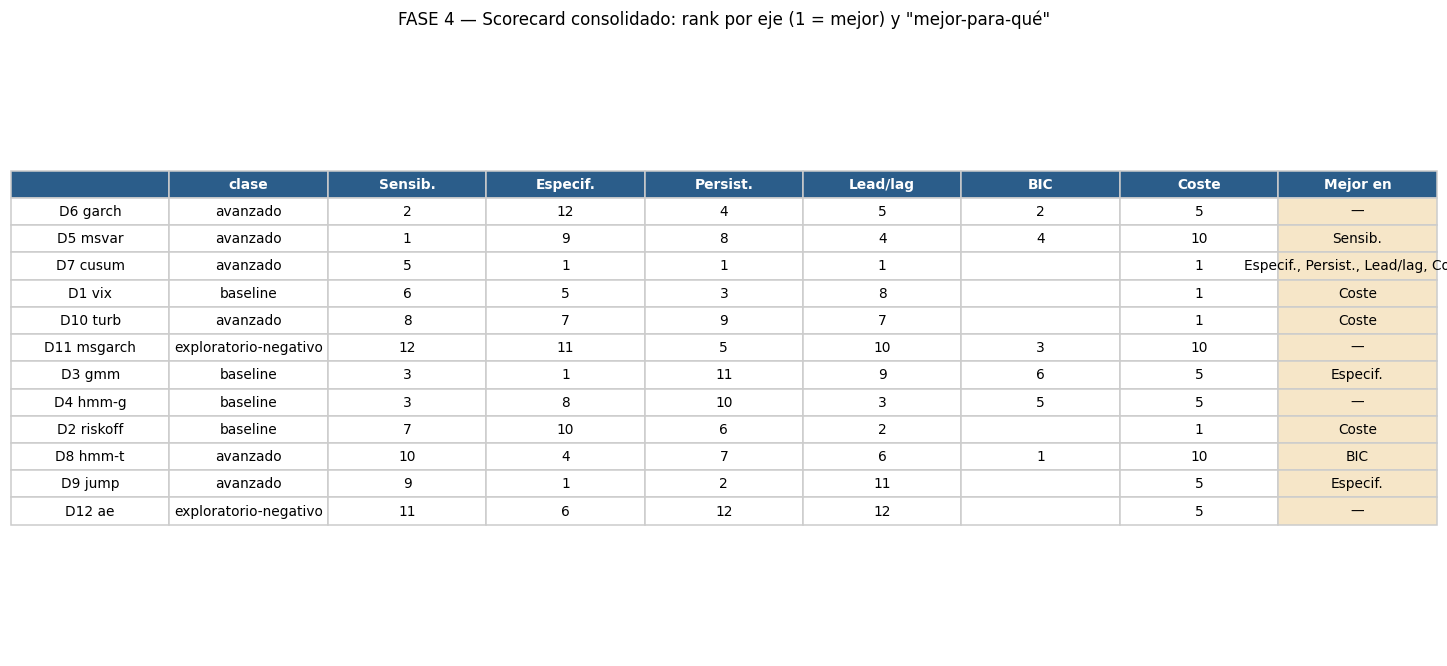

Guardado: results/synth_scorecard_table.png


In [9]:
# Scorecard: 12 detectores x 6 ejes (rank) + clase + "Mejor en".
sc = pd.DataFrame(index=[viz.detector_short(n) for n in ax.index])
sc['clase'] = ax['clase'].values
for label in rank6_spec:
    sc[label] = rank6[label].values
def _mejor_en(name):
    wins = [label for label in rank6_spec if rank6.loc[name, label] == 1]
    return ', '.join(wins) if wins else '—'
sc['Mejor en'] = [_mejor_en(n) for n in ax.index]

fig = viz.render_table_figure(
    sc, title='FASE 4 — Scorecard consolidado: rank por eje (1 = mejor) y "mejor-para-qué"',
    fmt={label: '{:.0f}' for label in rank6_spec}, highlight_cols=['Mejor en'])
fig.savefig(RESULTS / 'synth_scorecard_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: results/synth_scorecard_table.png')

<a id="sec6"></a>
## 6. Radar / spider por detector (`synth_radar.png`)

Cada detector tiene un **perfil** sobre los 6 ejes. Para verlo de un vistazo normalizamos cada
eje a **[0,1]** (min-max sobre los 12; *fuera = mejor* en todos: cobertura alta, especificidad
alta, persistencia alta, anticipación alta = lead/lag más negativo, coste bajo, BIC bajo) y
superponemos **4 detectores destacados** de familias distintas:

- **D1 `rule_vix`** (regla, F1): barata y específica, no anticipa.
- **D5 `msvar`** (Markov-switching VAR, F4): sensible a sistémicas, cara.
- **D7 `cusum`** (change-point, F6): anticipa y persiste; sin BIC comparable → 0 en "Ajuste".
- **D8 `hmm-t`** (HMM t-Student, F3): buen ajuste/estructura, ventana corta.

El **área** de cada polígono no mide "calidad total" (los ejes no son conmensurables); el valor
del radar es la **forma**: dónde es fuerte y dónde flojea cada familia.

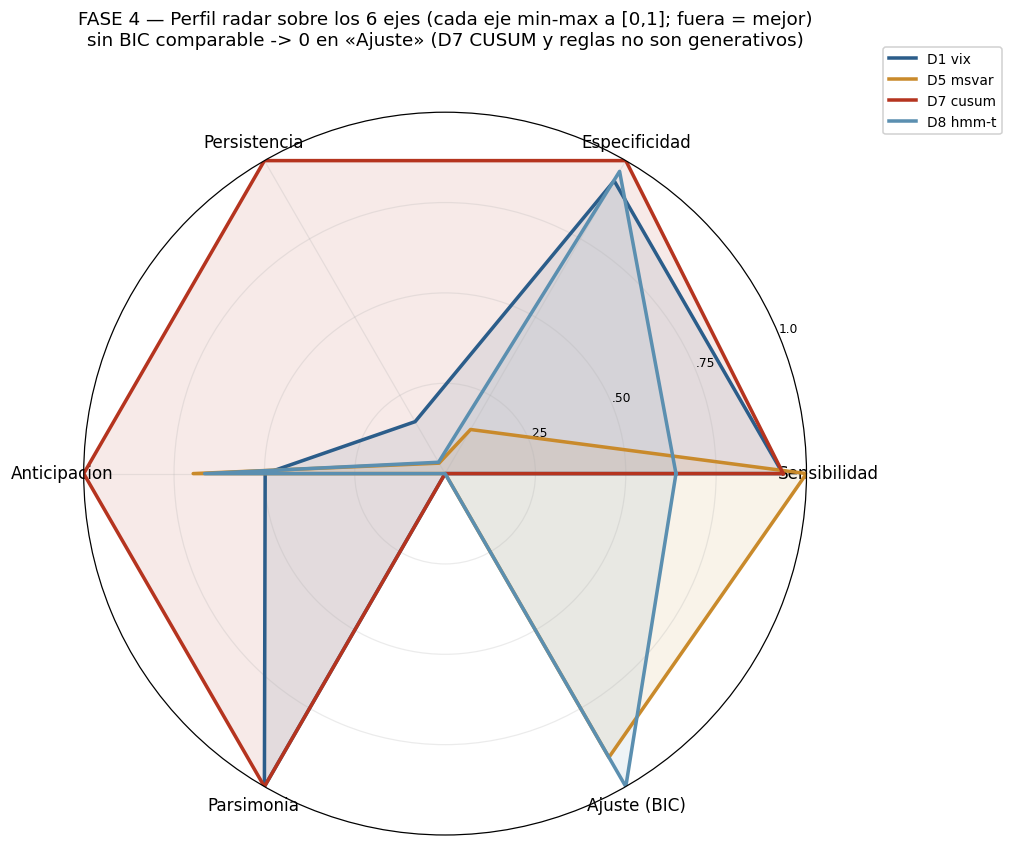

Guardado: results/synth_radar.png


In [10]:
# === FIGURA NUEVA: radar/spider por detector sobre los 6 ejes (perfil de un vistazo) ===
def _norm01(s, higher_better=True):
    s = s.astype(float)
    lo, hi = np.nanmin(s.values), np.nanmax(s.values)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi == lo:
        return pd.Series(0.5, index=s.index)
    z = (s - lo) / (hi - lo)
    return z if higher_better else (1 - z)

radar = pd.DataFrame(index=ax.index)
radar['Sensibilidad']  = _norm01(ax['eje1_cob_sistemica'], True)
radar['Especificidad'] = _norm01(ax['eje2_especif_estricta'], True)
radar['Persistencia']  = _norm01(ax['eje3_persistencia'], True)
radar['Anticipacion']  = _norm01(-ax['eje4_leadlag'], True)   # lead/lag mas negativo -> mas anticipacion
radar['Parsimonia']    = _norm01(ax['eje6_coste_num'], False) # coste bajo mejor
radar['Ajuste (BIC)']  = _norm01(ax['eje5_bic'], False)       # BIC bajo mejor
radar = radar.fillna(0.0)                                     # sin BIC comparable -> 0 en "Ajuste"

WANT = {'rule_vix_threshold', 'markov_switching_var', 'changepoint_online', 'hmm_tstudent'}
pick = sorted((n for n in ax.index if viz.canonical_detector(n) in WANT),
              key=lambda n: viz.detector_short(n))
labels = list(radar.columns)
ang = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist(); ang += ang[:1]
palette = [viz.C_LONG, viz.C_SHORT, viz.C_CRISIS, '#5b8fb0']

fig = plt.figure(figsize=(9.5, 9.5))
axp = plt.subplot(111, polar=True)
for i, n in enumerate(pick):
    v = radar.loc[n].tolist(); v += v[:1]
    c = palette[i % len(palette)]
    axp.plot(ang, v, color=c, lw=2.3, label=viz.detector_short(n))
    axp.fill(ang, v, color=c, alpha=0.10)
axp.set_xticks(ang[:-1]); axp.set_xticklabels(labels, fontsize=11)
axp.set_ylim(0, 1); axp.set_yticks([0.25, 0.5, 0.75, 1.0])
axp.set_yticklabels(['.25', '.50', '.75', '1.0'], fontsize=8)
axp.set_title('FASE 4 — Perfil radar sobre los 6 ejes (cada eje min-max a [0,1]; fuera = mejor)\n'
              'sin BIC comparable -> 0 en «Ajuste» (D7 CUSUM y reglas no son generativos)', y=1.08)
axp.legend(loc='upper right', bbox_to_anchor=(1.28, 1.10), framealpha=0.9)
fig.tight_layout(); fig.savefig(RESULTS / 'synth_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: results/synth_radar.png')

<a id="sec7"></a>
## 7. Podio por eje (`synth_podium_by_axis.png`)

Para cada uno de los **6 ejes**, el **top-3** de detectores (oro / plata / bronce). Es la lectura
más directa de la tesis: **ningún detector aparece en oro en todos los podios** — las 4 familias
se reparten los primeros puestos. Donde un eje tiene la salvedad de equidad de ventana
(cobertura), el podio se construye sobre los valores disponibles (NaN excluido, sin penalizar).

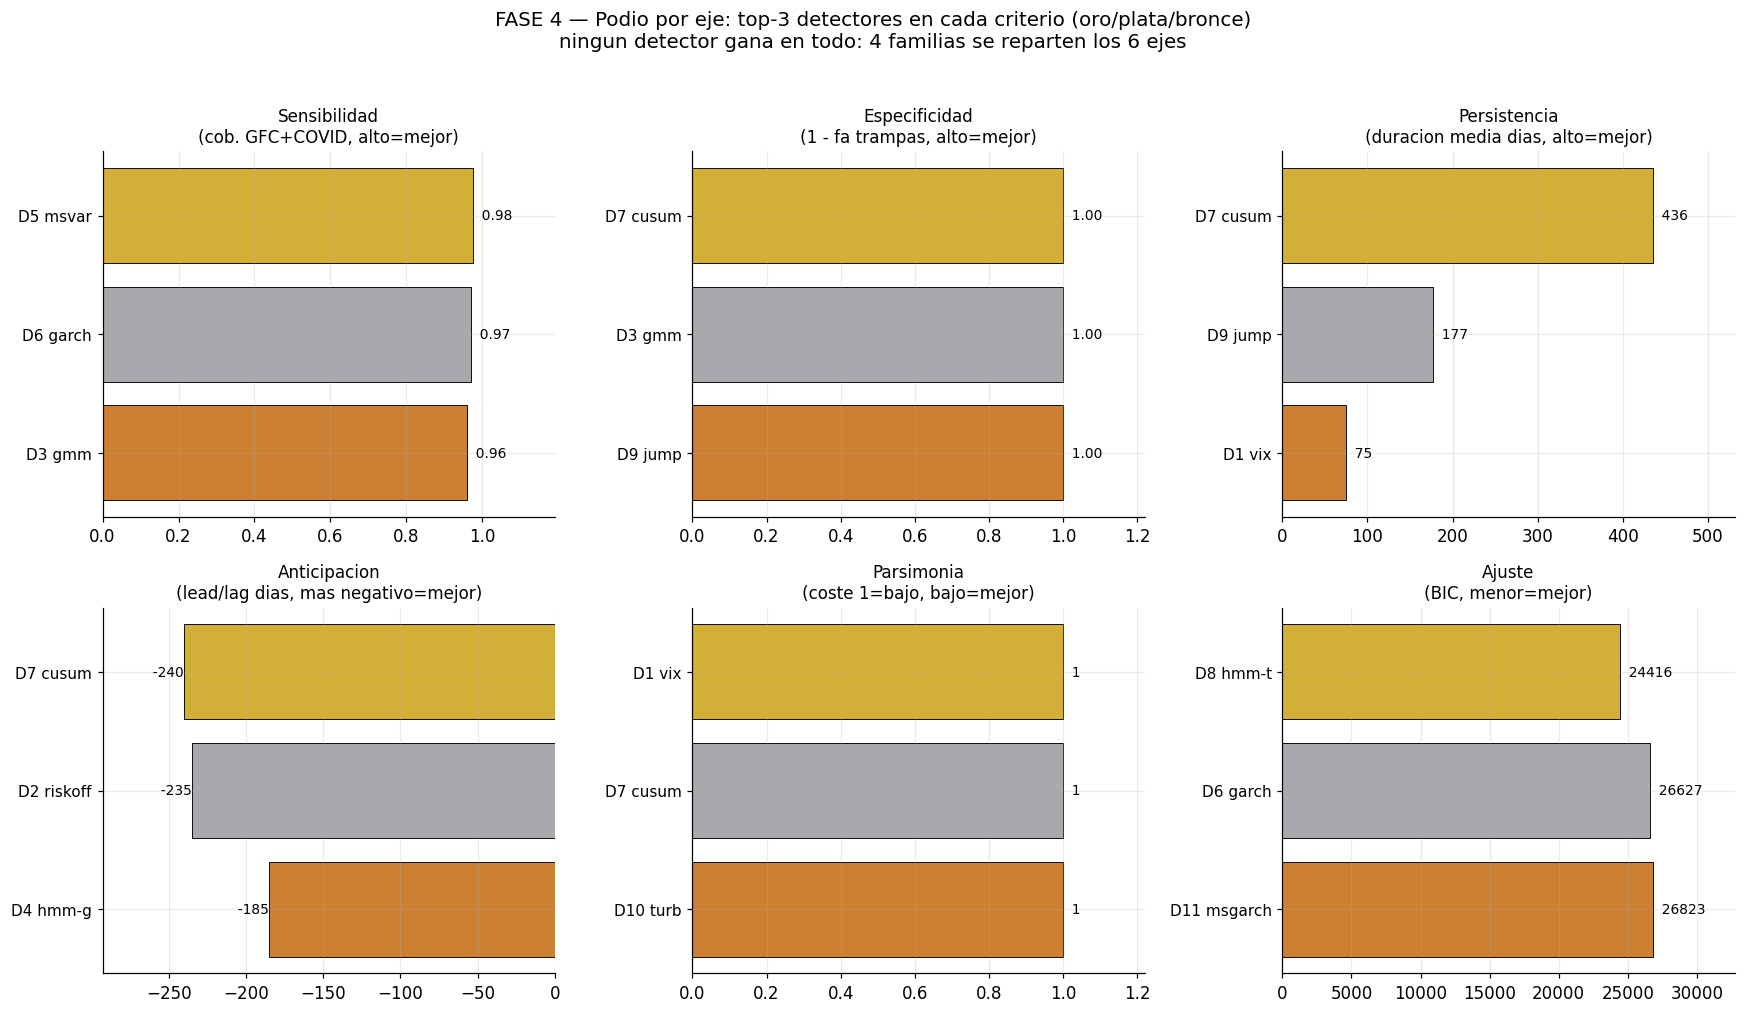

Guardado: results/synth_podium_by_axis.png


In [11]:
# === FIGURA NUEVA: podio (top-3) por cada uno de los 6 ejes ===
podium_axes = [
    ('Sensibilidad\n(cob. GFC+COVID, alto=mejor)', 'eje1_cob_sistemica', False, '{:.2f}'),
    ('Especificidad\n(1 - fa trampas, alto=mejor)', 'eje2_especif_estricta', False, '{:.2f}'),
    ('Persistencia\n(duracion media dias, alto=mejor)', 'eje3_persistencia', False, '{:.0f}'),
    ('Anticipacion\n(lead/lag dias, mas negativo=mejor)', 'eje4_leadlag', True, '{:.0f}'),
    ('Parsimonia\n(coste 1=bajo, bajo=mejor)', 'eje6_coste_num', True, '{:.0f}'),
    ('Ajuste\n(BIC, menor=mejor)', 'eje5_bic', True, '{:.0f}'),
]
medals = ['#d4af37', '#a8a9ad', '#cd7f32']   # oro, plata, bronce
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for axx, (ttl, col, asc, vf) in zip(axes.ravel(), podium_axes):
    s = ax[col].dropna().sort_values(ascending=asc).head(3)
    order = list(s.items())               # [(name, val), ...] mejor primero
    ypos = list(range(len(order)))[::-1]   # mejor arriba
    names = [viz.detector_short(n) for n, _ in order]
    vals = [v for _, v in order]
    cols = medals[:len(order)]
    axx.barh(ypos, vals, color=cols, edgecolor='black', linewidth=0.6)
    axx.set_yticks(ypos); axx.set_yticklabels(names, fontsize=10)
    axx.set_title(ttl, fontsize=11)
    axx.grid(alpha=0.25, axis='x')
    for y, (n, v) in zip(ypos, order):
        axx.text(v, y, '  ' + vf.format(v), va='center',
                 ha='left' if v >= 0 else 'right', fontsize=9)
    axx.margins(x=0.22)
fig.suptitle('FASE 4 — Podio por eje: top-3 detectores en cada criterio (oro/plata/bronce)\n'
             'ningun detector gana en todo: 4 familias se reparten los 6 ejes', y=1.02, fontsize=13)
fig.tight_layout(); fig.savefig(RESULTS / 'synth_podium_by_axis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: results/synth_podium_by_axis.png')

<a id="sec8"></a>
## 8. Planos de cruce de ejes (`results/synth_*.png`)

No tablas planas: **planos** que cruzan ejes para ver los trade-offs. Color por grupo de
ventana (vio 2008 o no); D11 y D12 marcados como **negativos**. Estas figuras conservan la
lógica de la síntesis previa pero se guardan con prefijo `synth_*` (las `fase4_*` se archivaron).

In [12]:
# Estilo comun de los planos
NEG = set(final.loc[final['clase'] == 'exploratorio-negativo', 'detector'])
def is_neg(name): return name in NEG
def color_for(row):
    if is_neg(row.name): return viz.C_NEG               # negativos en gris
    return viz.C_LONG if row['vio_2008_oos'] else viz.C_SHORT
SHORT = {n: viz.detector_short(n) for n in ax.index}    # nombres cortos robustos al K
print('paleta lista | negativos:', sorted(SHORT[n] for n in NEG))

paleta lista | negativos: ['D11 msgarch', 'D12 ae']


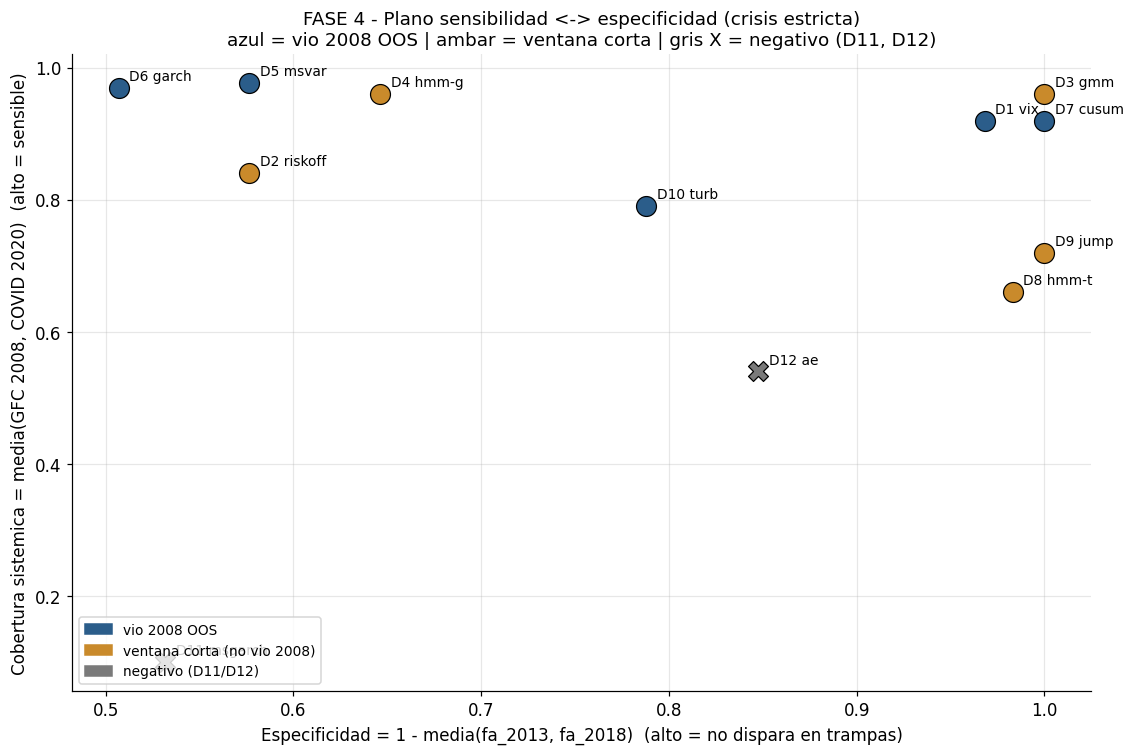

In [13]:
# FIG 1: plano SENSIBILIDAD (cobertura sistemica) vs ESPECIFICIDAD-trampas
fig, ax1 = plt.subplots(figsize=(10.5, 7))
for _, row in ax.iterrows():
    y = row['eje1_cob_sistemica']
    if y != y:   # sin cobertura sistemica evaluable -> se omite (equidad de ventana)
        continue
    c = color_for(row); mk = 'X' if is_neg(row.name) else 'o'
    ax1.scatter(row['eje2_especif_estricta'], y, s=170, c=c, marker=mk,
                edgecolor='black', linewidth=0.8, zorder=3)
    ax1.annotate(SHORT[row.name], (row['eje2_especif_estricta'], y),
                 textcoords='offset points', xytext=(7, 5), fontsize=9)
ax1.set_xlabel('Especificidad = 1 - media(fa_2013, fa_2018)  (alto = no dispara en trampas)')
ax1.set_ylabel('Cobertura sistemica = media(GFC 2008, COVID 2020)  (alto = sensible)')
ax1.set_title('FASE 4 - Plano sensibilidad <-> especificidad (crisis estricta)\n'
              'azul = vio 2008 OOS | ambar = ventana corta | gris X = negativo (D11, D12)')
ax1.grid(alpha=0.3)
ax1.legend(handles=[Patch(color=viz.C_LONG, label='vio 2008 OOS'),
                    Patch(color=viz.C_SHORT, label='ventana corta (no vio 2008)'),
                    Patch(color=viz.C_NEG, label='negativo (D11/D12)')], loc='lower left')
fig.tight_layout(); fig.savefig(RESULTS / 'synth_sensibilidad_especificidad.png', dpi=150, bbox_inches='tight')
plt.show()

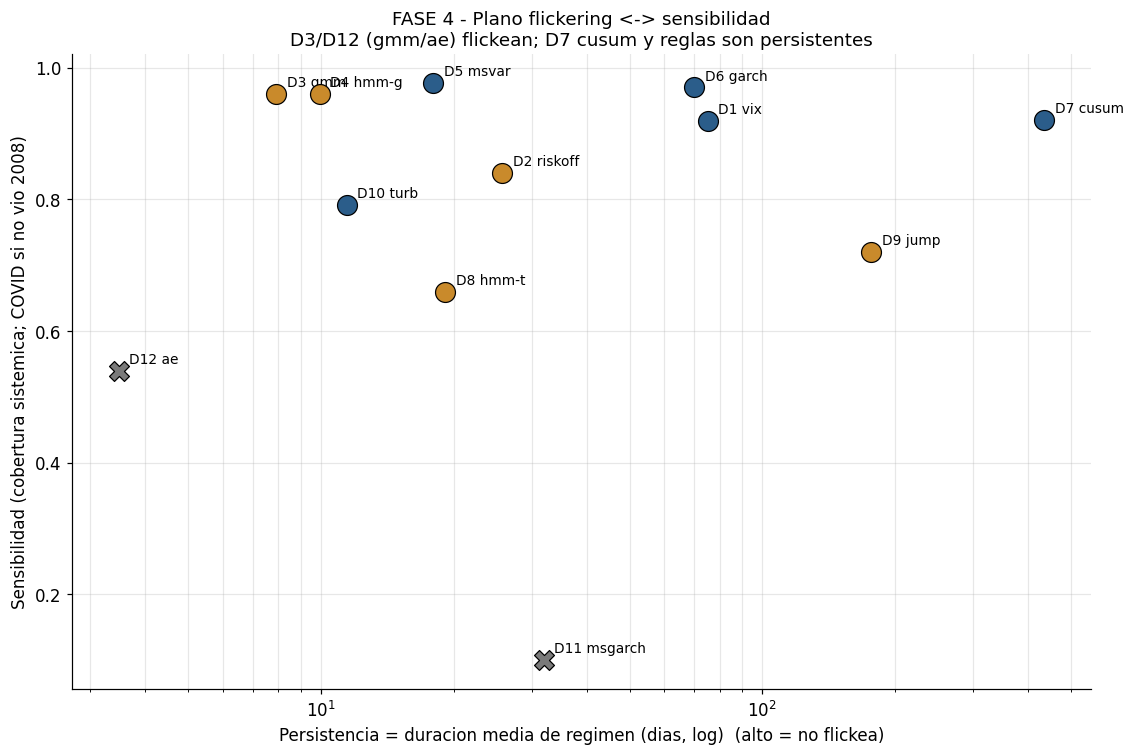

In [14]:
# FIG 2: plano PERSISTENCIA (anti-flickering) vs SENSIBILIDAD (cobertura)
fig, ax2 = plt.subplots(figsize=(10.5, 7))
for _, row in ax.iterrows():
    y = row['eje1_cob_sistemica']
    yv = y if y == y else np.nanmean([row['cov_COVID_2020']])  # fallback a COVID si no vio sistemicas grandes
    c = color_for(row); mk = 'X' if is_neg(row.name) else 'o'
    ax2.scatter(row['mean_regime_duration'], yv, s=170, c=c, marker=mk,
                edgecolor='black', linewidth=0.8, zorder=3)
    ax2.annotate(SHORT[row.name], (row['mean_regime_duration'], yv),
                 textcoords='offset points', xytext=(7, 5), fontsize=9)
ax2.set_xscale('log')
ax2.set_xlabel('Persistencia = duracion media de regimen (dias, log)  (alto = no flickea)')
ax2.set_ylabel('Sensibilidad (cobertura sistemica; COVID si no vio 2008)')
ax2.set_title('FASE 4 - Plano flickering <-> sensibilidad\n'
              'D3/D12 (gmm/ae) flickean; D7 cusum y reglas son persistentes')
ax2.grid(alpha=0.3, which='both')
fig.tight_layout(); fig.savefig(RESULTS / 'synth_persistencia_sensibilidad.png', dpi=150, bbox_inches='tight')
plt.show()

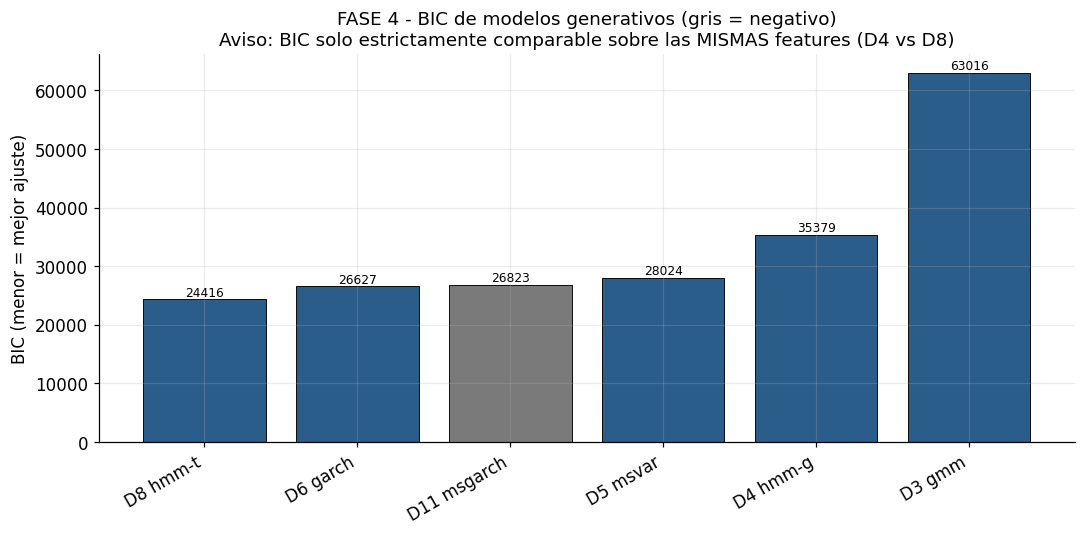

In [15]:
# FIG 3: BIC (solo modelos generativos). Menor = mejor.
bic_s = ax['bic'].dropna().sort_values()
fig, ax3 = plt.subplots(figsize=(10, 5))
cols = [viz.C_NEG if is_neg(n) else viz.C_LONG for n in bic_s.index]
ax3.bar([SHORT[n] for n in bic_s.index], bic_s.values, color=cols, edgecolor='black', linewidth=0.6)
ax3.set_ylabel('BIC (menor = mejor ajuste)')
ax3.set_title('FASE 4 - BIC de modelos generativos (gris = negativo)\n'
              'Aviso: BIC solo estrictamente comparable sobre las MISMAS features (D4 vs D8)')
for i, (n, v) in enumerate(bic_s.items()):
    ax3.text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=8, rotation=0)
plt.xticks(rotation=30, ha='right')
fig.tight_layout(); fig.savefig(RESULTS / 'synth_bic.png', dpi=150, bbox_inches='tight')
plt.show()

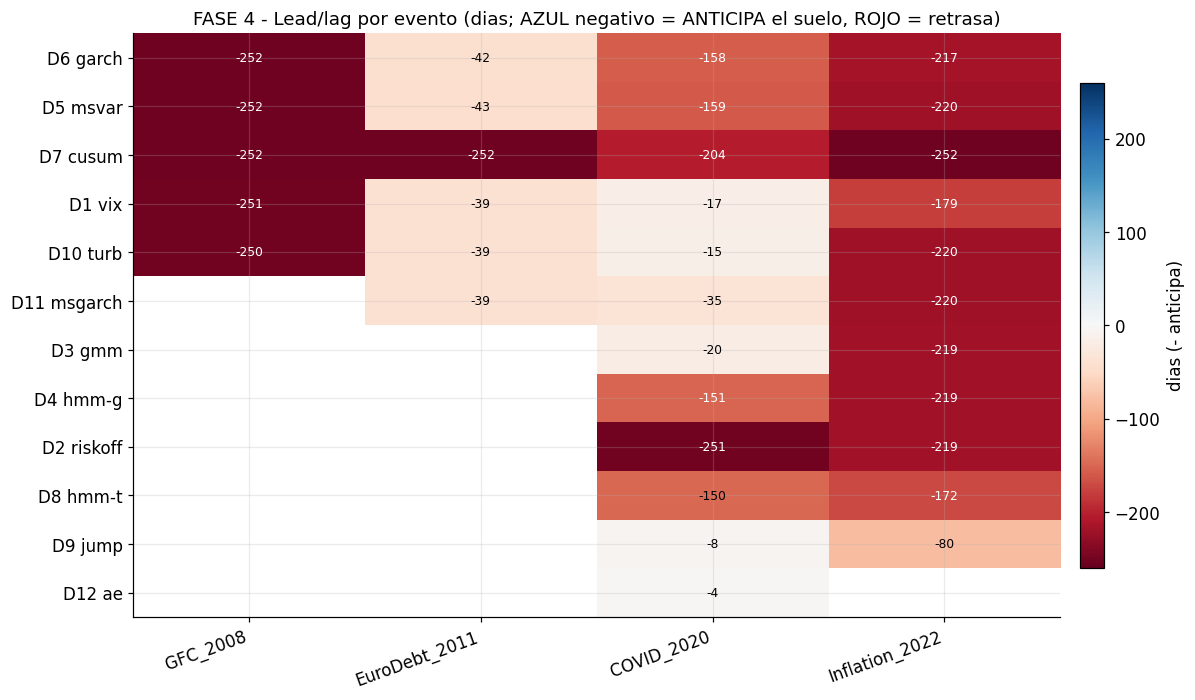

In [16]:
# FIG 4: lead/lag por evento (negativo = anticipa el suelo del drawdown)
events = list(TROUGH)
det_order = [n for n in ax.index]
M = np.array([[ax.loc[n, f'leadlag_{w}'] for w in events] for n in det_order], dtype=float)
fig, ax4 = plt.subplots(figsize=(11, 6.5))
im = ax4.imshow(M, aspect='auto', cmap='RdBu', vmin=-260, vmax=260)
ax4.set_xticks(range(len(events))); ax4.set_xticklabels(events, rotation=20, ha='right')
ax4.set_yticks(range(len(det_order))); ax4.set_yticklabels([SHORT[n] for n in det_order])
for i in range(len(det_order)):
    for j in range(len(events)):
        v = M[i, j]
        if v == v:
            ax4.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=8,
                     color='white' if abs(v) > 150 else 'black')
ax4.set_title('FASE 4 - Lead/lag por evento (dias; AZUL negativo = ANTICIPA el suelo, ROJO = retrasa)')
fig.colorbar(im, ax=ax4, fraction=0.025, pad=0.02, label='dias (- anticipa)')
fig.tight_layout(); fig.savefig(RESULTS / 'synth_leadlag.png', dpi=150, bbox_inches='tight')
plt.show()

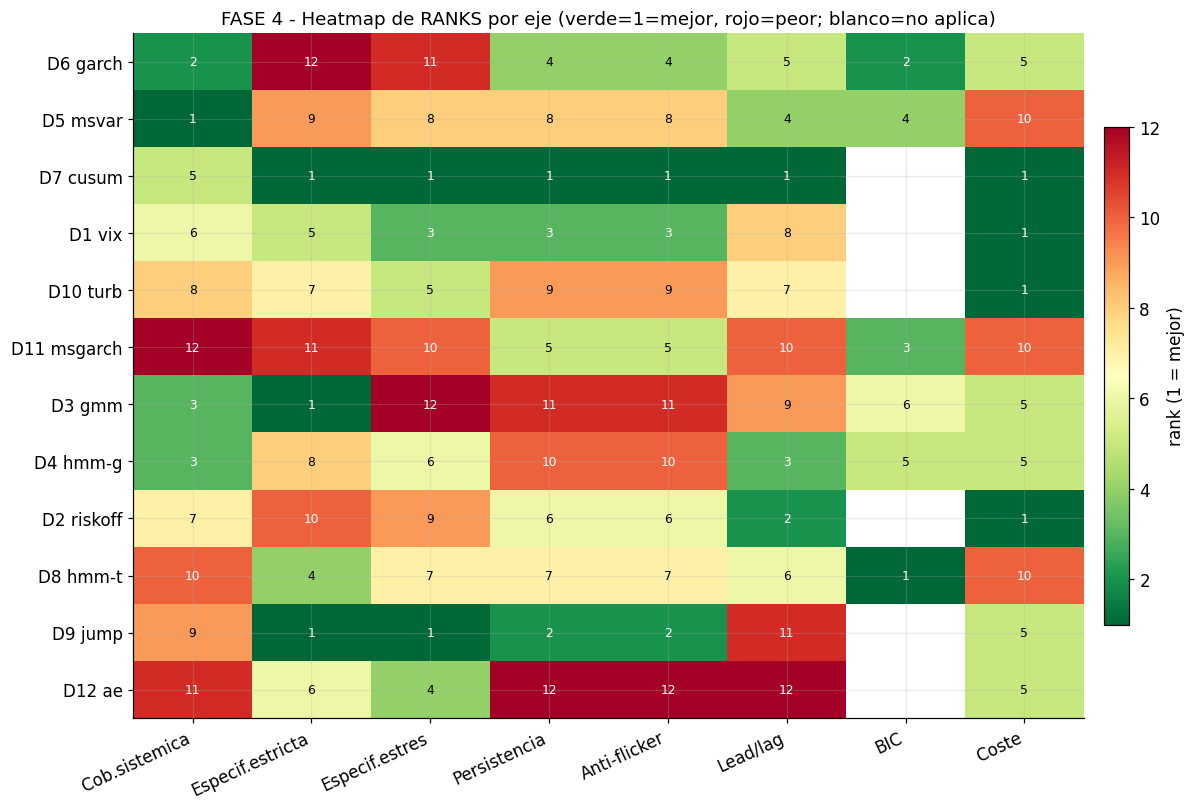

In [17]:
# FIG 5: heatmap de RANKS por eje (detectores x ejes; 1 = mejor)
R = ranks.copy()
fig, ax5 = plt.subplots(figsize=(11, 7.5))
im = ax5.imshow(R.values, aspect='auto', cmap='RdYlGn_r', vmin=1, vmax=12)
ax5.set_xticks(range(R.shape[1])); ax5.set_xticklabels(R.columns, rotation=25, ha='right')
ax5.set_yticks(range(R.shape[0])); ax5.set_yticklabels([SHORT[n] for n in R.index])
for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        v = R.values[i, j]
        if v == v:
            ax5.text(j, i, f'{int(v)}', ha='center', va='center', fontsize=8,
                     color='white' if (v <= 3 or v >= 10) else 'black')
ax5.set_title('FASE 4 - Heatmap de RANKS por eje (verde=1=mejor, rojo=peor; blanco=no aplica)')
fig.colorbar(im, ax=ax5, fraction=0.025, pad=0.02, label='rank (1 = mejor)')
fig.tight_layout(); fig.savefig(RESULTS / 'synth_rank_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

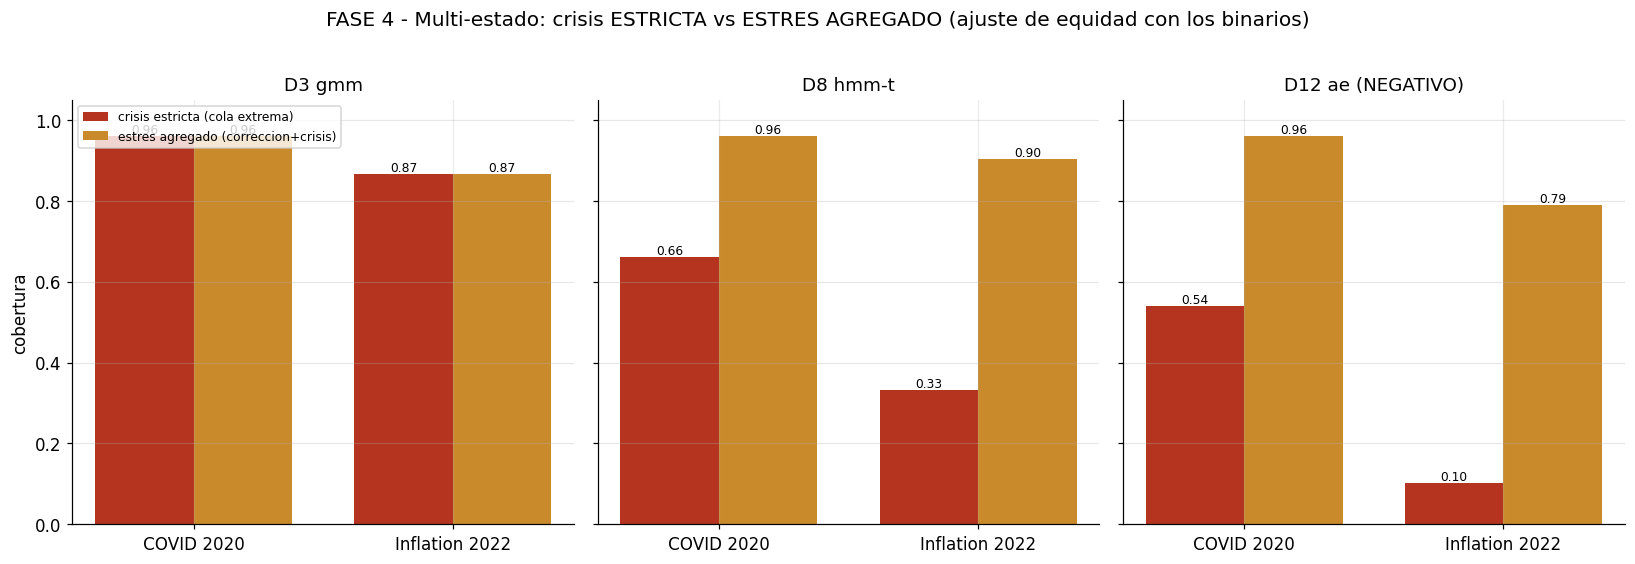

=== Multi-estado: activacion en TRAMPAS estricta vs estres (el otro lado, honesto) ===

D3 gmm:
  TaperTantrum_2013: estricta=nan  ->  estres=nan
  Selloff_Q4_2018 : estricta=0.000  ->  estres=0.729

D8 hmm-t:
  TaperTantrum_2013: estricta=0.000  ->  estres=0.000
  Selloff_Q4_2018 : estricta=0.034  ->  estres=0.814

D12 ae:
  TaperTantrum_2013: estricta=nan  ->  estres=nan
  Selloff_Q4_2018 : estricta=0.153  ->  estres=0.186


In [18]:
# FIG 6: crisis ESTRICTA vs ESTRES para los 3 multi-estado (corazon del ajuste de equidad)
multi_names = ['clustering_gmm_k3', 'hmm_tstudent_4s', 'deep_ae_regime']
wins = ['cov_COVID_2020', 'cov_Inflation_2022']   # ventanas OOS comunes a los 3
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for axx, name in zip(axes, multi_names):
    r = final[final['detector'] == name].iloc[0]
    estr = [r[w] for w in wins]
    estres = [r[w.replace('cov_', 'cov_estres_')] for w in wins]
    xx = np.arange(len(wins)); w = 0.38
    b1 = axx.bar(xx - w/2, estr, w, label='crisis estricta (cola extrema)', color=viz.C_CRISIS)
    b2 = axx.bar(xx + w/2, estres, w, label='estres agregado (correccion+crisis)', color=viz.C_SHORT)
    axx.set_xticks(xx); axx.set_xticklabels(['COVID 2020', 'Inflation 2022'])
    neg = ' (NEGATIVO)' if is_neg(name) else ''
    axx.set_title(SHORT[name] + neg); axx.set_ylim(0, 1.05); axx.grid(alpha=0.3, axis='y')
    for b in list(b1) + list(b2):
        axx.text(b.get_x() + b.get_width()/2, b.get_height(), f'{b.get_height():.2f}',
                 ha='center', va='bottom', fontsize=8)
axes[0].set_ylabel('cobertura'); axes[0].legend(loc='upper left', fontsize=8)
fig.suptitle('FASE 4 - Multi-estado: crisis ESTRICTA vs ESTRES AGREGADO (ajuste de equidad con los binarios)', y=1.02)
fig.tight_layout(); fig.savefig(RESULTS / 'synth_estres_vs_estricta.png', dpi=150, bbox_inches='tight')
plt.show()

# fa en trampas: el otro lado (ampliar a correccion puede subir la activacion en 2013/2018)
print('=== Multi-estado: activacion en TRAMPAS estricta vs estres (el otro lado, honesto) ===')
for name in multi_names:
    r = final[final['detector'] == name].iloc[0]
    print(f'\n{SHORT[name]}:')
    for w in FP:
        print(f'  {w:16s}: estricta={r[f"fa_{w}"]:.3f}  ->  estres={r[f"fa_estres_{w}"]:.3f}')

<a id="sec9"></a>
## 9. RESUMEN ESTRUCTURADO (para redactar las conclusiones)

Ranking por eje, números estrés vs crisis estricta de los multi-estado, y qué familia gana en
qué eje. Es el insumo de las conclusiones de la FASE 4: el veredicto **"mejor-para-qué"**.

In [19]:
print('='*78)
print('RESUMEN ESTRUCTURADO - FASE 4')
print('='*78)

def top(col, asc, k=3):
    s = ax[col].dropna()
    s = s.sort_values(ascending=asc)
    return [(viz.detector_short(n), round(float(v), 3)) for n, v in list(s.items())[:k]]

print('\n--- RANKING POR EJE (top-3; 1 = mejor) ---')
print('1. Cobertura sistemica (GFC+COVID, solo quien la vio OOS):')
for grp, sub in ax.groupby('vio_2008_oos'):
    tag = 'VIO 2008 OOS' if grp else 'ventana corta (no vio 2008)'
    s = sub['eje1_cob_sistemica'].dropna().sort_values(ascending=False)
    print(f'     [{tag}] ' + ', '.join(f'{viz.detector_short(n)}={v:.2f}' for n, v in s.items()))
print('2. Especificidad estricta (1-fa trampas):', top('eje2_especif_estricta', False))
print('   Especificidad estres                 :', top('eje2_especif_estres', False))
print('3. Persistencia (dur media, dias)        :', top('eje3_persistencia', False))
print('   Anti-flicker (switching bajo)         :', top('eje3_switching', True))
print('4. Lead/lag (mas negativo = anticipa)    :', top('eje4_leadlag', True))
print('5. BIC (menor = mejor; solo generativos) :', top('eje5_bic', True))
print('6. Coste (bajo = mejor)                  :', top('eje6_coste_num', True))

print('\n--- ESTRES AGREGADO vs CRISIS ESTRICTA (multi-estado D3, D8, D12) ---')
for name in ['clustering_gmm_k3', 'hmm_tstudent_4s', 'deep_ae_regime']:
    r = final[final['detector'] == name].iloc[0]
    print(f'\n {viz.detector_short(name)} (k={int(r["n_states"])})  {r["nota"]}')
    for w in ['COVID_2020', 'Inflation_2022']:
        print(f'   cov_{w:14s}: estricta={r[f"cov_{w}"]:.3f}  ->  estres={r[f"cov_estres_{w}"]:.3f}'
              f'   (delta={r[f"cov_estres_{w}"]-r[f"cov_{w}"]:+.3f})')
    for w in ['TaperTantrum_2013', 'Selloff_Q4_2018']:
        ce, ee = r[f'fa_{w}'], r[f'fa_estres_{w}']
        print(f'   fa_{w:15s}: estricta={ce:.3f}  ->  estres={ee:.3f}   (delta={ee-ce:+.3f})')
    print(f'   false_alarm_rate: estricta={r["false_alarm_rate"]:.3f} -> estres={r["false_alarm_rate_estres"]:.3f}')

print('\n--- QUE FAMILIA GANA EN QUE EJE ---')
def winner(col, asc):
    s = ax[col].dropna(); return viz.detector_short(s.idxmin() if asc else s.idxmax())
print(f'  Cobertura sistemica (ventana larga) : {winner("eje1_cob_sistemica", False)}  '
      '(reglas/vol/MS-VAR: familias F1/F4/F5)')
print(f'  Especificidad (no trampas)          : {winner("eje2_especif_estricta", False)}  (CUSUM F6 / reglas F1)')
print(f'  Persistencia / anti-flicker         : {winner("eje3_persistencia", False)}  (change-point F6)')
print(f'  Lead/lag (anticipacion)             : {winner("eje4_leadlag", True)}  (change-point F6)')
print(f'  Ajuste BIC (generativos)            : {winner("eje5_bic", True)}  (GARCH-t F5 / HMM-t F3)')
print(f'  Coste (mas barato)                  : {winner("eje6_coste_num", True)}  (reglas F1 / CUSUM F6)')

print('\n--- RESULTADOS NEGATIVOS (validan parsimonia) ---')
for name in ['msgarch_regime', 'deep_ae_regime']:
    r = final[final['detector'] == name].iloc[0]
    print(f'  {viz.detector_short(name):12s}: clase={r["clase"]}, cov_GFC={r["cov_GFC_2008"]}, '
          f'switching={r["switching_rate"]:.3f}, far={r["false_alarm_rate"]:.3f}')
print('\nVeredicto: NO hay detector dominante; 4 familias se reparten los 6 ejes -> "mejor-para-que".')
print('Entregables (figuras): results/synth_radar.png, synth_scorecard_table.png, synth_podium_by_axis.png,')
print('  synth_sensibilidad_especificidad.png, synth_persistencia_sensibilidad.png, synth_bic.png,')
print('  synth_leadlag.png, synth_rank_heatmap.png, synth_estres_vs_estricta.png')
print('NOTA: este notebook NO escribe ningun CSV en results/ (solo LEE metrics_master.csv).')
print('='*78)

RESUMEN ESTRUCTURADO - FASE 4

--- RANKING POR EJE (top-3; 1 = mejor) ---
1. Cobertura sistemica (GFC+COVID, solo quien la vio OOS):
     [ventana corta (no vio 2008)] D3 gmm=0.96, D4 hmm-g=0.96, D2 riskoff=0.84, D9 jump=0.72, D8 hmm-t=0.66, D12 ae=0.54
     [VIO 2008 OOS] D5 msvar=0.98, D6 garch=0.97, D7 cusum=0.92, D1 vix=0.92, D10 turb=0.79, D11 msgarch=0.10
2. Especificidad estricta (1-fa trampas): [('D7 cusum', 1.0), ('D3 gmm', 1.0), ('D9 jump', 1.0)]
   Especificidad estres                 : [('D7 cusum', 1.0), ('D9 jump', 1.0), ('D1 vix', 0.968)]
3. Persistencia (dur media, dias)        : [('D7 cusum', 435.684), ('D9 jump', 176.6), ('D1 vix', 75.204)]
   Anti-flicker (switching bajo)         : [('D7 cusum', 0.002), ('D9 jump', 0.005), ('D1 vix', 0.013)]
4. Lead/lag (mas negativo = anticipa)    : [('D7 cusum', -240.0), ('D2 riskoff', -235.0), ('D4 hmm-g', -185.0)]
5. BIC (menor = mejor; solo generativos) : [('D8 hmm-t', 24415.887), ('D6 garch', 26626.562), ('D11 msgarch', 26823.3